
Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [1]:
%load_ext autoreload
%autoreload 2
from __future__ import annotations
import os
import sys
from pathlib import Path
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import shutil
import time
from datetime import datetime
from joblib import Parallel, delayed  # from functools import partial #for specific type of parallel deployment

#load preprocess specific functions
import notebook_setup
info = notebook_setup.setup()
from run_manifest import create_run_manifest, update_run_database
from config_preprocessing import load_config
from analysis_config_loader import load_analysis_config  # new import, personal config 

preprocess_func_folder = Path(info["repo_root"]) / "preprocess_functions"
sys.path.append(str(preprocess_func_folder)) #add preprocess_functions folder to path to load modules
from detect_cell_enrichment import get_cell_stage_enrichment, get_cell_ensemble_info_per_subject
from matlab_obj_to_python import load_matlab_object, check_corrupted_files, load_all_matlab_objects
from preprocessing_utils import dataset_obj_to_df, transform_all_datasets, get_intercol_corrs, read_shuffle_parquet_from_folder, extract_trial_windows, create_subject_trial_tseries_df
from preprocess_functions.shuffle_methods import prepare_shuffle_data, create_shuffled_df_preconverted, log_shuffle_run, get_latest_shuffle_folder, load_latest_shuffle_run
from preprocess_data import hyper_param_dict, bin_rotate_timeseries, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, drop_end_bins_of_trials, drop_start_bins_of_trials, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import annotate_csv, run_min_max_norm_on_timeseries

# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sns_plotting_config import * #import dicts containing default plot params

# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


<Figure size 640x480 with 0 Axes>

#### Define file config variables and analysis parameters ####

In [2]:
# set up locations for input/output 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)

#import local yaml for env preset variables
config_path = Path(r"analysis_config.yaml")  # adjust as needed
analysis_config = load_analysis_config(config_path)
stage_names = analysis_config.task_phase_names
print(analysis_config)

# Load general file configuration
config = load_config('config.yaml')
data_type = config['data']['data_type_used']
preprocessing = config['preprocessing']
shuffle_cfg = config['shuffles']
print(config)

# Create unique run ID
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
START_TIME = time.time()

# Create output directory with run ID
results_dir = config['data']['results_dir']
run_output_dir = results_dir / 'shuffles' / f"shuffle_run_{RUN_ID}"
run_output_dir.mkdir(parents=True, exist_ok=True)

#set data location
data_dir = config['data']['data_dir']
source_dataset_location= config['data']['source_dataset_location']

#hardcoded/old links for checking
hardcode_results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")
hardcode_data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')
hardcode_source_dataset_location = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19") #source dataset location has files created 10-26-2024

#print config paths for verification
print(f"Run ID: {RUN_ID}, Started: {datetime.now()}")
print(f"\nFolders used in run ID: {RUN_ID}")
print(f"Results dir: {results_dir}")
print(f"Data dir: {data_dir}")
print(f"Source dataset location: {source_dataset_location}")

# Copy config to output directory for reference
shutil.copy('config.yaml', run_output_dir / 'config_used.yaml')

AnalysisConfig(trial_section_names=['pre_outcome', 'post_outcome', 'ITI'], phase_division_types=['simple', 'complex'], task_phase_names=['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'], simple_phase_names=['IA_Error', 'IA_Correct', 'RS_Error', 'RS_Correct'], feature_type_names=['correct_error', 'IA_RS', 'task_phase'], phase_is_solo_vector=True, shuffle_to_use='circle', num_shuffles=1000, early_division_criteria_types=['count', 'first_2'], early_criteria_type='count', early_criteria_value=5, trial_section_divisions=[], corr_vector_is_triangular=True, seconds_before_post_to_keep=5, time_series_bin_size=0.25, corr_time_series_bin_size=0.5, percentile=95, threshold_with_shuffle=True, min_baseline_len=12000, final_thresh=2.5, final_thresh2=12.5, final_thresh3=20, final_thresh4_abs=0.01, drop_low_value_peak_events=False, drop_low_act_cell_in_dataset_obj=False, low_act_thresh_in_obj_init=0.005, cutoff_filter='bimodality', peak_event_cutoff_per

WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/results/shuffles/shuffle_run_20251209_145452/config_used.yaml')

#### Set what analysis to do

In [3]:
#set parameters
data_types = ['raster', 'dff']
data_type_used = data_types[0] #OR, 'dff'
run_activity_enrichment = True
#normalization
normalize = config['preprocessing']['normalization']
if data_type_used== 'raster':
    normalize = 'none'
print(f"Applying normalization: {normalize} on {data_type_used} data")

# Option 1: Global seed sequence across all subjects
run_shuffles = False  #set to True to run shuffles
n_shuf_per_subject = config['shuffles']['n_shuffles_per_subject'] #default = 5000
n_shuf_per_subject = 10000
## Configuration #200 minutes for 5000 shuffles/subject on 14 cores
n_jobs=  config['shuffles']['n_cores'] -2 #base =  psutil.cpu_count(logical=False)-2  #leave 2 cores free
base_seed = config['shuffles']['base_seed'] #default: 42

Applying normalization: none on raster data


In [4]:
loaded_objects = load_all_matlab_objects(source_dataset_location, expected_count=35)


Found 35 files in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19
Loading 1/35: 10_3_HET_RS1: 150415 cells × 136 frames
Loading 2/35: 10_3_HET_RS2: 97940 cells × 168 frames
Loading 3/35: 10_3_HET_RS3: 108794 cells × 157 frames
Loading 4/35: 13_3_HET_RS1: 191533 cells × 160 frames
Loading 5/35: 13_3_HET_RS2: 108651 cells × 145 frames
Loading 6/35: 13_3_HET_RS3: 128277 cells × 147 frames
Loading 7/35: 13_4_WT_RS1: 153831 cells × 183 frames
Loading 8/35: 13_4_WT_RS2: 106245 cells × 171 frames
Loading 9/35: 13_5_HET_RS1: 229350 cells × 120 frames
Loading 10/35: 13_5_HET_RS2: 141283 cells × 125 frames
Loading 11/35: 13_5_HET_RS3: 96995 cells × 131 frames
Loading 12/35: 13_6_WT_RS1: 206081 cells × 247 frames
Loading 13/35: 13_6_WT_RS2: 145514 cells × 246 frames
Loading 14/35: 13_8_HET_RS1: 124098 cells × 207 frames
Loading 15/35: 13_8_HET_RS2: 111694 cells × 206 frames
Loading 16/35: 13_8_HET_RS3: 126723 cells × 244 frames
Lo

#### Extract and Transform Matlab Objects into stage-labeled dataframes

In [5]:
### testing
test_df = dataset_obj_to_df(loaded_objects[0],config, analysis_config,  datatype = 'raster', normalize = 'none') #test 1 dataset
print(test_df.info())
print(test_df.sample())

 Dropping 15 cells w. 0 activity: ['cell_2', 'cell_7', 'cell_8', 'cell_18', 'cell_27', 'cell_31', 'cell_36', 'cell_44', 'cell_59', 'cell_68', 'cell_74', 'cell_80', 'cell_103', 'cell_108', 'cell_121']
Processed raster of 10_3_HET_RS1: 163651520 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 135487 entries, frame_14928 to frame_150414
Columns: 132 entries, cell_1 to truncated_post
dtypes: Int16(1), Sparse[int32, 0](121), bool(2), int32(1), object(7)
memory usage: 16.4+ MB
None
              cell_1  cell_3  cell_4  cell_5  cell_6  cell_9  cell_10  \
frame_148303       0       0       0       0       0       0        0   

              cell_11  cell_12  cell_13  ...  normalized  datatype  \
frame_148303        0        0        0  ...        none    raster   

              subject_name  geno  session  drop_inactive_cells  trial_num  \
frame_148303  10_3_HET_RS1   HET      RS1                 True         40   

              task_stage  trial_section  truncated_post  
frame_148303   

In [6]:
test_meta = test_df[['labels',  'normalized', 'datatype', 'subject_name', 'geno', 'session', 'drop_inactive_cells', 'trial_num', 'task_stage', 'trial_section', 'truncated_post']]
print(test_meta.groupby(by = 'trial_section')['labels'].value_counts())
test_meta.sample()

trial_section  labels
ITI            15        62787
               8         26320
post_outcome   12         8520
               13         5520
               5          5220
               14         2660
               7          1840
               6          1040
pre_outcome    11        10460
               10         3700
               9          2420
               4          2040
               3          1640
               2          1320
Name: count, dtype: Int64


,labels,normalized,datatype,subject_name,geno,session,drop_inactive_cells,trial_num,task_stage,trial_section,truncated_post
frame_24958,8,none,raster,10_3_HET_RS1,HET,RS1,True,4,Early_IA_Correct,ITI,True


In [7]:
# raster_dataframes= transform_all_datasets(loaded_objects,config, analysis_config, datatype = data_type_used, normalize = normalize)

##CREATE DATAFRAMES
#RASTER- Loop over imported objects by subject and create pandas DataFrames, containing RASTERS
raster_dataframes_spikes = transform_all_datasets(loaded_objects, config, analysis_config, datatype = 'raster', normalize = 'none')

# DFF- Loop over imported objects by subject and create pandas DataFrames, containing DFF
raster_dataframes_dff = transform_all_datasets(loaded_objects, config, analysis_config, datatype = 'dff', normalize = 'baseline_zscore')

 Dropping 15 cells w. 0 activity: ['cell_2', 'cell_7', 'cell_8', 'cell_18', 'cell_27', 'cell_31', 'cell_36', 'cell_44', 'cell_59', 'cell_68', 'cell_74', 'cell_80', 'cell_103', 'cell_108', 'cell_121']
Processed raster of 10_3_HET_RS1: 163651520 bytes
 Dropping 17 cells w. 0 activity: ['cell_13', 'cell_16', 'cell_32', 'cell_35', 'cell_38', 'cell_40', 'cell_41', 'cell_49', 'cell_57', 'cell_59', 'cell_65', 'cell_75', 'cell_97', 'cell_115', 'cell_120', 'cell_135', 'cell_168']
Processed raster of 10_3_HET_RS2: 131631360 bytes
 Dropping 14 cells w. 0 activity: ['cell_10', 'cell_22', 'cell_26', 'cell_38', 'cell_40', 'cell_45', 'cell_50', 'cell_81', 'cell_87', 'cell_101', 'cell_103', 'cell_134', 'cell_136', 'cell_143']
Processed raster of 10_3_HET_RS3: 136645264 bytes
 Dropping 8 cells w. 0 activity: ['cell_4', 'cell_23', 'cell_28', 'cell_41', 'cell_91', 'cell_94', 'cell_97', 'cell_139']
Processed raster of 13_3_HET_RS1: 245162240 bytes
 Dropping 10 cells w. 0 activity: ['cell_54', 'cell_65', '

In [8]:
n_subjects = len(raster_dataframes_spikes)
shuffle_storage_folder, all_subject_shuffles = load_latest_shuffle_run(results_dir)

 Loading from folder: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_08-Dec-2025_10000 shuffles\shuffled_dfs_10000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run


#### Within python latest shuffle run, compare within chunk stability


In [9]:
def chunk_shuffles_by_subject(all_subject_shuffles: Dict[str, pd.DataFrame], raster_dataframes: Dict[str, pd.DataFrame], chunk_size: int = 1000) -> pd.DataFrame:
    """ Chunk shuffles by subject into smaller sets for enrichment analysis.
    Inputs:
    all_subject_shuffles : Dict of subject_name to shuffled mean activity DataFrame
    raster_dataframes : Dict of subject_name to raster DataFrame
    chunk_size : number of unique seeds per chunk
    Returns: pd.DataFrame of combined enrichment results across all subject-chunks"""
    # Separate shuffles into chunks of 1000 unique seeds PER SUBJECT
    print(f"Chunking shuffles by subject (chunk_size={chunk_size})")
    chunked_ensemble_results = []
    # Loop over each subject
    for subject_name, shuffle_df in all_subject_shuffles.items():
        # Get unique seeds for THIS subject
        subject_unique_seeds = sorted(shuffle_df['shuffle_seed'].unique())
        n_seeds = len(subject_unique_seeds)
        n_chunks = n_seeds // chunk_size
        print(f"=== Processing subject: {subject_name}. total seeds: {n_seeds}, {n_chunks} chunks ===")
        # Get corresponding raster data
        subject_raster_df = raster_dataframes[subject_name]
        cell_col = [c for c in subject_raster_df.columns if c.startswith('cell_')]
        
        # Loop over chunks for this subject
        for chunk_idx in range(n_chunks):
            # Get specific seeds for this chunk
            start_idx = chunk_idx * chunk_size
            end_idx = (chunk_idx + 1) * chunk_size
            chunk_seeds = subject_unique_seeds[start_idx:end_idx]
            chunk_shuffle_df = shuffle_df.loc[shuffle_df['shuffle_seed'].isin(chunk_seeds),:] # Filter shuffles for this chunk
            # Run enrichment analysis for this subject-chunk
            chunk_ensembles = get_cell_stage_enrichment(all_shuffle_means=chunk_shuffle_df, raster_df=subject_raster_df, n_shuf_per_subject=len(chunk_seeds))
            # Add metadata
            chunked_ensemble_results.append(chunk_ensembles.assign(**{'subject_name': subject_name,'chunk_index': chunk_idx, 'chunk_seed_min': chunk_seeds[0],'chunk_seed_max': chunk_seeds[-1],'n_seeds_in_chunk': len(chunk_seeds)}))

    # Combine all subject-chunk results
    all_chunked_ensembles = pd.concat(chunked_ensemble_results, ignore_index=True)
    print(f"Processed {all_chunked_ensembles['subject_name'].nunique()} Subjects into {all_chunked_ensembles.shape} shaped DF")
    print(f"Chunks per subject: {all_chunked_ensembles.groupby('subject_name')['chunk_index'].max() + 1}")
    return all_chunked_ensembles

## pivot chunked ensembles activation and plot heatmap
def get_pivoted_enrichment_heatmap(all_chunked_ensembles: pd.DataFrame, pivot_values = 'enriched') -> pd.DataFrame:
    """ Pivot chunked ensemble enrichment results and plot heatmap of correlations.
    Inputs: all_chunked_ensembles : DataFrame with columns ['subject_name', 'task_stage', 'cell', 'chunk_index', 'enriched']
    Returns: Pivoted DataFrame of enrichment by chunk"""

    enriched_by_chunk = all_chunked_ensembles.pivot_table(index=['subject_name', 'task_stage', 'cell'], columns='chunk_index',values=pivot_values,aggfunc='first')
    enriched_by_chunk.columns = [f'chunk_{i}' for i in enriched_by_chunk.columns]
    enriched_by_chunk=enriched_by_chunk.reset_index()
    return enriched_by_chunk

#### import raw shuffle data for DFF and spikes, to compare shuffle chunk similarity

In [10]:
# spikes_shuffle_path = results_dir / Path(f"raster_none_norm_ensemble_detection_06-Dec-2025_5000 shuffles/shuffled_dfs_5000_per_subject")
spikes_shuffle_path = get_latest_shuffle_folder(results_dir, 'raster')
print(f"Loading shuffles from {spikes_shuffle_path}")
all_shuffles_spikes =  read_shuffle_parquet_from_folder(spikes_shuffle_path) # Load all parquet files from that folder
all_chunk_ens_spikes = chunk_shuffles_by_subject(all_shuffles_spikes, raster_dataframes_spikes, chunk_size=1000)
enriched_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes)
enriched_by_chunk_spikes.head()


Loading shuffles from C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_08-Dec-2025_10000 shuffles\shuffled_dfs_10000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run
Chunking shuffles by su

,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4,chunk_5,chunk_6,chunk_7,chunk_8,chunk_9
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False,False,False,False,False,False
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False,False,False,False,False,False
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False,False,False,False,False,False
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False,False,False,False,False,False
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False,False,False,False,False,False


In [11]:
#Then, get dff ensemble output: 
dff_shuffle_path = get_latest_shuffle_folder(results_dir, 'dff')
print(f"Loading shuffles from {dff_shuffle_path}")
all_shuffles_dff =  read_shuffle_parquet_from_folder(dff_shuffle_path) # Load all parquet files from that folder
#if you are importing something that's NOT the current data type used, make sure to re-create raster dataframes for that datatype
all_chunk_ens_dff = chunk_shuffles_by_subject(all_shuffles_dff, raster_dataframes_dff, chunk_size=1000)
enriched_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunk_ens_dff)
enriched_by_chunk_dff.head()


Loading shuffles from C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_10000 shuffles\shuffled_dfs_10000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run
Chunking shuffl

c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked

=== Processing subject: 13_3_HET_RS2. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_3_HET_RS3. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_4_WT_RS1. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_4_WT_RS2. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_5_HET_RS1. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_5_HET_RS2. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_5_HET_RS3. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_6_WT_RS1. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_6_WT_RS2. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_8_HET_RS1. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_8_HET_RS2. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_8_HET_RS3. total seeds: 10000, 10 chunks ===
=== Processing subject: 14_2_WT_RS1. total seeds: 10000, 10 chunks ===
=== Processing subject: 14_2_WT_RS2. total seeds: 10000, 10 chunks ==

,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4,chunk_5,chunk_6,chunk_7,chunk_8,chunk_9
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False,False,False,False,False,False
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False,False,False,False,False,False
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False,False,False,False,False,False
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False,False,False,False,False,False
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False,False,False,False,False,False


#### Plot correlation of spike and dff data enrichment

In [12]:
def plot_stage_correlation_heatmaps(enrich_compared_df: pd.DataFrame, 
                                   stage_names: list, 
                                   merge_chunk_col: list,
                                   value_compared: str,
                                   axes: np.ndarray,
                                   grid_shape: tuple = (2, 3),
                                   vmin: float = 0.5,
                                   cmap: str = 'viridis') -> None:
    """Plot correlation heatmaps for each task stage on a subplot grid."""
    nrows, ncols = grid_shape
    
    for s, stage in enumerate(stage_names):
        ax = axes.flatten()[s]
        row, col = s // ncols, s % ncols
        
        # Compute and plot correlation for this stage
        stage_vals = enrich_compared_df[enrich_compared_df['task_stage'] == stage][merge_chunk_col].corr()
        sns.heatmap(stage_vals, vmin=vmin, cmap=cmap, ax=ax)
        
        # Remove ticks if not on edges
        if col != 0: ax.set_yticks([])
        if row != nrows - 1: ax.set_xticks([])
        
        ax.set_title(f"{stage.replace('_', ' ')}: {value_compared} correlations")

Figure saved: dff_vs_spikes_ensemble_membership_vector_chunkcorrs.jpg | In: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results


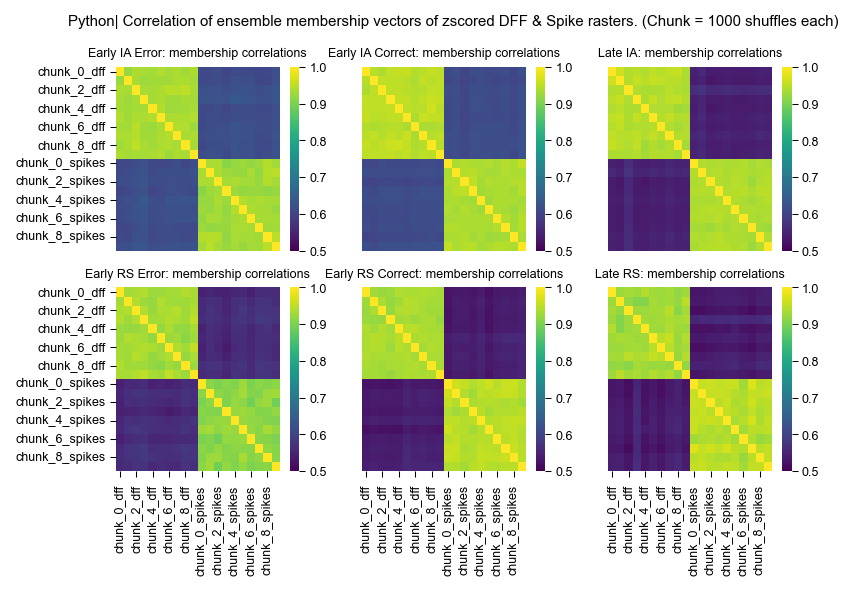

In [ ]:

merged_enriched_chunks = pd.merge(enriched_by_chunk_dff, enriched_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))
# Plot correlation heatmaps
value_compared = "membership"
fig, axes = plt.subplots(2, 3, figsize=(6,3.5))
plot_stage_correlation_heatmaps(enrich_compared_df=merged_enriched_chunks, stage_names=stage_names, merge_chunk_col=[c for c in merged_enriched_chunks.columns if 'chunk_' in c], value_compared=value_compared, axes = axes)
fig.suptitle(f"Python| Correlation of ensemble {value_compared} vectors of zscored DFF & Spike rasters. (Chunk = 1000 shuffles each)")
# Save figure
fig_filename = f"dff_vs_spikes- ensemble_{value_compared}_vector_chunkcorrs.jpg"
fig.savefig(results_dir / fig_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved: {fig_filename} | In: {results_dir}")

Figure saved: dff_vs_spikes_ensemble_p-value_vector_chunkcorrs.jpg | In: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results


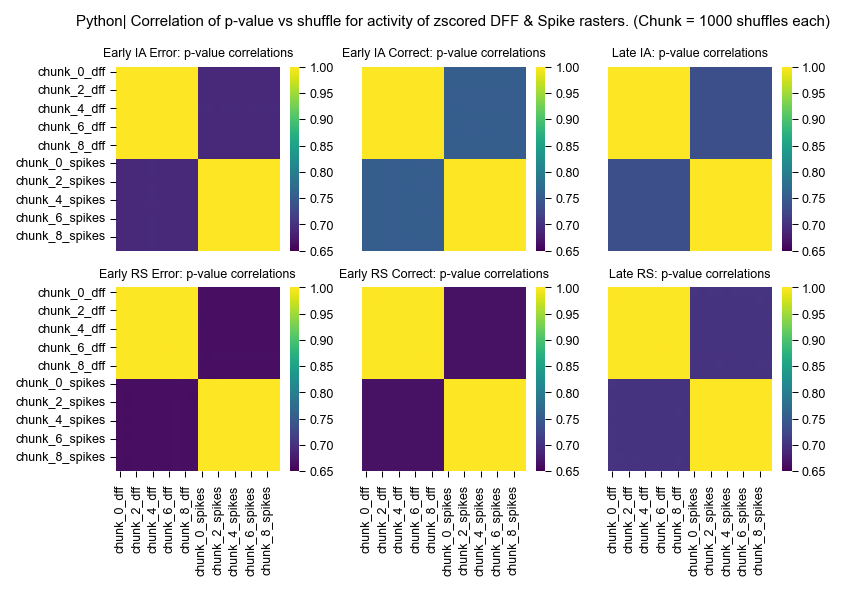

In [ ]:
#use pvalue for corr 
pval_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes, pivot_values = 'percent_shuffle >= real')
pval_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunk_ens_dff, pivot_values = 'percent_shuffle >= real')
merge_pval_chunks = pd.merge(pval_by_chunk_dff, pval_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))

# Plot correlation heatmaps
value_compared = "p-value"
fig, axes = plt.subplots(2, 3, figsize=(6,3.5))
plot_stage_correlation_heatmaps(enrich_compared_df=merge_pval_chunks, stage_names=stage_names, merge_chunk_col=[c for c in merge_pval_chunks.columns if 'chunk_' in c], value_compared=value_compared, vmin = 0.65, axes = axes)
fig.suptitle(f"Python| Correlation of {value_compared} vs shuffle for activity of zscored DFF & Spike rasters. (Chunk = 1000 shuffles each)")
# Save figure
fig_filename = f"dff_vs_ensembles_by_datatype['raster']emble_{value_compared}_vector_chunkcorrs.jpg"
fig.savefig(results_dir / fig_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved: {fig_filename} | In: {results_dir}")

#### import both DFF & spike ensemble parquets


In [ ]:
#store both dff and spike ensembles dataframes in dict
ensembles_by_datatype, ensemble_table_by_datatype, ensemble_pvals_by_datatype = {}, {}, {}


In [61]:
# import DFF ensemble matrix- baseline Zscored
dff_ens_path = list(get_latest_shuffle_folder(results_dir, 'dff').parent.glob("*.parquet"))[0]
print(f"loading: {dff_ens_path}")
ensembles_by_datatype['dff'] = pd.read_parquet(dff_ens_path)
print(ensembles_by_datatype['dff'].info())
ensembles_by_datatype['dff'].tail(2)

loading: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_10000 shuffles\dff_postoutcome_python_ensembles_10000_shuff_07-Dec-2025_.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39534 entries, 0 to 39533
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               39534 non-null  object 
 1   cell                     39534 non-null  object 
 2   percentile_95            39520 non-null  float64
 3   mean                     39520 non-null  float32
 4   enriched                 39534 non-null  bool   
 5   percent_shuffle >= real  39534 non-null  float64
 6   subject_name             39534 non-null  object 
 7   neuron_id                39534 non-null  object 
 8   date_made                39534 non-null  object 
 9   n_shuffles               39534 non-null  int64  
 10  data_type 

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
39532,Late_RS,cell_215,0.726587,0.001032,False,0.3358,9_3_HET_RS3,9_3_HET_RS3-215,07-Dec-2025,10000,dff
39533,truncated_post_outcome,cell_215,0.174152,-0.165721,False,0.9979,9_3_HET_RS3,9_3_HET_RS3-215,07-Dec-2025,10000,dff


In [58]:
#import last spikes ensemble matrix for comparison #non normalized mean spike rate for the means 
raster_ensemble_path = list(get_latest_shuffle_folder(results_dir, 'raster').parent.glob("*.parquet"))[0]
print(f"Loading: {raster_ensemble_path}") # raster_ensemble_path = results_dir / Path(r"raster_none_norm_ensemble_detection_06-Dec-2025_5000 shuffles\raster_postoutcome_python_ensembles_5000_shuff_06-Dec-2025_.parquet")
ensembles_by_datatype['raster'] = pd.read_parquet(raster_ensemble_path)
print(ensembles_by_datatype['raster'].info())
ensembles_by_datatype['raster'].tail(2)

Loading: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_08-Dec-2025_10000 shuffles\raster_postoutcome_python_ensembles_10000_shuff_08-Dec-2025_.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38199 entries, 0 to 38198
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               38199 non-null  object 
 1   cell                     38199 non-null  object 
 2   percentile_95            38199 non-null  float64
 3   mean                     38199 non-null  float64
 4   enriched                 38199 non-null  bool   
 5   percent_shuffle >= real  38199 non-null  float64
 6   subject_name             38199 non-null  object 
 7   neuron_id                38199 non-null  object 
 8   date_made                38199 non-null  object 
 9   n_shuffles               38199 non-null  int64  
 10  data_type      

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
38197,Late_RS,cell_99,0.018333,0.000000,False,1.0000,9_3_HET_RS3,9_3_HET_RS3-99,08-Dec-2025,10000,raster
38198,truncated_post_outcome,cell_99,0.006127,0.002014,False,0.6078,9_3_HET_RS3,9_3_HET_RS3-99,08-Dec-2025,10000,raster


In [ ]:
## pivot both binary enrichment vectors
ensemble_table_by_datatype['raster'] = ensembles_by_datatype['raster'].pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)
ensemble_table_by_datatype['dff'] = ensembles_by_datatype['dff'].pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)

## pivot both p-value matrices by datatype
ensemble_pvals_by_datatype['raster'] = ensembles_by_datatype['raster'].pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)
ensemble_pvals_by_datatype['dff'] = ensembles_by_datatype['dff'].pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)


#### Analysis: Compare ensemble pvalue & enrichment between zscored dff & spike raster

In [71]:
## merge both enrichment vectors for comparison 
raster_dff_ens_vecs = ensemble_table_by_datatype['raster'].merge(ensemble_table_by_datatype['dff'], on = 'neuron_id', suffixes=('_spikes', '_dff'))
raster_dff_ens_corr_df = get_intercol_corrs(raster_dff_ens_vecs, stage_names, suffix1="_spikes", suffix2="_dff")

## merge both spike + dff pvalue matrices
raster_dff_ens_pvals =  ensemble_pvals_by_datatype['raster'].merge(ensemble_pvals_by_datatype['dff'], on = 'neuron_id', suffixes=('_spikes', '_dff'))
ens_pval_corr_df = get_intercol_corrs(raster_dff_ens_pvals, stage_names, suffix1="_spikes", suffix2="_dff")

## print summary:
print(f" Correlation of ensemble enrichment (vs. shuffle), between z-scored df/F data & spike rasters \n{raster_dff_ens_corr_df}")
print(f" Correlation of ensemble activity p-value (vs. shuffle), between z-scored df/F data & spike rasters: \n{ens_pval_corr_df}")

 Correlation of ensemble enrichment (vs. shuffle), between z-scored df/F data & spike rasters 
                  Correlation
Early_IA_Error       0.624613
Early_IA_Correct     0.614595
Late_IA              0.550077
Early_RS_Error       0.574041
Early_RS_Correct     0.525900
Late_RS              0.535796
 Correlation of ensemble activity p-value (vs. shuffle), between z-scored df/F data & spike rasters: 
                  Correlation
Early_IA_Error       0.782424
Early_IA_Correct     0.753088
Late_IA              0.734657
Early_RS_Error       0.663554
Early_RS_Correct     0.666088
Late_RS              0.702068


#### Threshold time-series df to remove 0 

In [ ]:
#for concordance with previous code, need to label the stage col as 'task_stage_vec
stage_col = 'task_phase_vec'

def normalize_tseries_df(trial_tseries_df_raw: pd.DataFrame,
                          n_end_timebins_to_drop = config['timeseries']['n_end_timebins_to_drop'], #default = 0,
                          n_start_timebins_to_drop = config['timeseries']['n_start_timebins_to_drop'], #default = 8,
                          name_col: str = 'subject_name',
                          neuron_id_col: str = 'neuron_id',
                          ) -> pd.DataFrame:
    """ Normalize trial time-series DataFrame based on normalization type.
    Inputs:
    trial_tseries_df_raw : DataFrame with raw time-series data (ALREADY BINNED)
    hyper_param_dict : dictionary of hyperparameters
    outcome_post : DataFrame with outcome post data

    Returns: Normalized trial time-series DataFrame
    """
    #get normalization info for curr df
    normed = trial_tseries_df_raw['normalized'].unique()[0]
    if normed == 'none':
        use_min_max_norm = True 
    else:
        use_min_max_norm = False
    print(f" Data Normalization type: {normed} | Applying min-max norm? {use_min_max_norm} ")

    numeric_col = get_numeric_cols_timeseries(trial_tseries_df_raw, " to ") 
    #is min-max norm run BEFORE or AFTER bin dropping? 
    trial_tseries_df_norm = run_min_max_norm_on_timeseries(use_min_max_norm, trial_tseries_df_raw, [name_col, neuron_id_col], numeric_col, 'max_trial_val') #min_max_norm = True

    #get mean of each trial- IS this run BEFORE or AFTER norm? 
    trial_tseries_df_norm['mean_rate'] =trial_tseries_df_norm[[c for c in numeric_col if '-' not in c]].mean(axis = 1) #mean rate is post outcome only
    trial_tseries_df_norm['active_in_trial'] =trial_tseries_df_norm['mean_rate']>0

    #OPTIONAL- drop N bins from start and M bins from end of time-series
    #first, check if you're pre-truncated the data (e.g. already only sliced 3 seconds before outcome)
    neg_timebins = [c for c in numeric_col if "-" in c]
    if len(neg_timebins) <4*3+1: #if you only have 1 second or so of pre-outcome data, you've already sliced 
        n_start_timebins_to_drop = 0
    trial_tseries_df_norm = drop_end_bins_of_trials(trial_tseries_df_norm,numeric_col,  n_end_timebins_to_drop = n_end_timebins_to_drop )
    trial_tseries_df_norm = drop_start_bins_of_trials(trial_tseries_df_norm,numeric_col,  n_start_timebins_to_drop =n_start_timebins_to_drop)
    return trial_tseries_df_norm

def normalize_all_subject_tseries_dfs(raster_base_dfs: Dict[str, pd.DataFrame],
                                      config = config, 
                                      n_end_timebins_to_drop = 0,
                                      n_start_timebins_to_drop = 8,
                                      name_col: str = 'subject_name',
                                      neuron_id_col: str = 'neuron_id',
                                      ) -> pd.DataFrame:
    """ Normalize all subject trial time-series DataFrames.
    Inputs:     raster_base_dfs : Dict of subject_name to raw full recording matrix DataFrame
    optional settings for time-series normalization that equal defaults, so left un input

    Returns: concat. dataframe of subject_name to normalized trial time-series DataFrame
    """

    raster_timeseries =[]
    for name, raster_df in raster_base_dfs.items():
        print(f" Reshaping tseries of {name}: {raster_df.shape}")    
        subj_trial_tseries_df_raw= create_subject_trial_tseries_df(raster_df, ensemble_table_by_datatype['dff'], config = config)
        subj_trial_tseries_df_norm= normalize_tseries_df(subj_trial_tseries_df_raw)
        raster_timeseries.append(subj_trial_tseries_df_norm)
    trial_tseries_df_norm = pd.concat(raster_timeseries)
    return trial_tseries_df_norm

In [ ]:
trial_tseries_df_norm = normalize_all_subject_tseries_dfs(raster_dataframes_spikes, config = config)
#save filename with data type and date info
save_name = results_dir / Path(f"python-made_trial_timeseries_{data_type_used}_{datetime.now().strftime("%Y-%m-%d %H")}.parquet")
print(f"saving file as {save_name}")
trial_tseries_df_norm.to_parquet(save_name)
##
trial_tseries_df_norm.tail(3)


 Reshaping tseries of 10_3_HET_RS1: (135487, 132)
Using 0 pre-outcome frames


In [73]:

# get mean time-series value
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")  #update post drop
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], ['subject_name', 'neuron_id','geno_day', stage_col], numeric_col) 
unit_mean_tseries.tail(3)


,subject_name,neuron_id,geno_day,task_phase_vec,-3.0s to -2.75s,-2.75s to -2.5s,-2.5s to -2.25s,-2.25s to -2.0s,-2.0s to -1.75s,-1.75s to -1.5s,...,Late_IA,Late_RS,truncated_post_outcome,any_enrichment,enriched_in_phase,max_trial_val,mean_rate,active_in_trial,max_val,max_val_tbin
27606,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_RS_Error,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,False,1.0,0.000000,False,0.0,-3.0s to -2.75s
27607,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Late_IA,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,False,1.0,0.009333,True,0.2,4.0s to 4.25s
27608,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Late_RS,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,False,1.0,0.000000,False,0.0,-3.0s to -2.75s


In [ ]:
n_total_units = unit_mean_tseries.groupby(by = 'geno_day')['neuron_id'].nunique()
print(f"{n_total_units.sum()} total units":)
print(n_total_units)


geno_day
Het CLNZ         858
Het VEH          873
Het postCLNZ     934
WT CLNZ         1013
WT VEH          1071
Name: neuron_id, dtype: int64
4749
saving file as C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\python-made_trial_timeseries_raster_2025-12-09 15.parquet


#### Import canon ensemble + tseries to compare umap

In [25]:
# import canonical ensemble matrix previously created in MATLAB, used for paper #find old file- 
canonical_file = data_dir / Path(r"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet")
canonical_data = pd.read_parquet(canonical_file) #normalized spike rates for the means 
print(canonical_data.info())

canonical_data

<class 'pandas.core.frame.DataFrame'>
Index: 93253 entries, 0 to 116376
Data columns (total 93 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   task_phase_vec     93253 non-null  object 
 1   IA_RS_vec          93253 non-null  object 
 2   corr_err_vec       93253 non-null  object 
 3   trial_num          93253 non-null  int64  
 4   neuron_ID          93253 non-null  int64  
 5   name               93253 non-null  object 
 6   day                93253 non-null  int32  
 7   geno               93253 non-null  object 
 8   geno_day           93253 non-null  object 
 9   -3.0s to -2.75s    93253 non-null  float64
 10  -2.75s to -2.5s    93253 non-null  float64
 11  -2.5s to -2.25s    93253 non-null  float64
 12  -2.25s to -2.0s    93253 non-null  float64
 13  -2.0s to -1.75s    93253 non-null  float64
 14  -1.75s to -1.5s    93253 non-null  float64
 15  -1.5s to -1.25s    93253 non-null  float64
 16  -1.25s to -1.0s    93253 n

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,name,day,geno,geno_day,-3.0s to -2.75s,...,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial
0,Early_IA_Correct,IA,Correct,1,1,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False
2,Early_IA_Correct,IA,Correct,1,3,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-3,1.0,0.000000,False
3,Early_IA_Correct,IA,Correct,1,4,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,1.0,0.0,0.0,False,1.0,10_3_HET_RS1-4,1.0,0.000000,False
4,Early_IA_Correct,IA,Correct,1,5,10_3_HET_RS1,1,HET,Het VEH,1.0,...,0.0,0.0,0.0,0.0,False,0.0,10_3_HET_RS1-5,1.0,0.193333,True
5,Early_IA_Correct,IA,Correct,1,6,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,0.0,10_3_HET_RS1-6,1.0,0.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116370,Late_RS,RS,Correct,38,209,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,1.0,9_3_HET_RS3-209,1.0,0.020000,True
116373,Late_RS,RS,Correct,38,212,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,2.0,9_3_HET_RS3-212,1.0,0.030000,True
116374,Late_RS,RS,Correct,38,213,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,0.0,9_3_HET_RS3-213,1.0,0.000000,False
116375,Late_RS,RS,Correct,38,214,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,0.0,9_3_HET_RS3-214,1.0,0.200000,True


In [26]:
#get canon mean unit timeseries
numeric_col_canon = get_numeric_cols_timeseries(canonical_data, " to ")  #update post drop\
canon_mean_unit_tseries  =  get_unit_mean_timeseries_by_phase(canonical_data,['trial_num'], ['name', 'neuron_ID','geno_day', stage_col], numeric_col) 
print(canon_mean_unit_tseries.groupby(by = 'geno_day')['unique_ID'].nunique())
print(canon_mean_unit_tseries.info())
canon_mean_unit_tseries


geno_day
Het CLNZ         866
Het VEH          874
Het postCLNZ     937
WT CLNZ         1019
WT VEH          1080
Name: unique_ID, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27768 entries, 0 to 27767
Data columns (total 94 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               27768 non-null  object 
 1   neuron_ID          27768 non-null  int64  
 2   geno_day           27768 non-null  object 
 3   task_phase_vec     27768 non-null  object 
 4   -3.0s to -2.75s    27768 non-null  float64
 5   -2.75s to -2.5s    27768 non-null  float64
 6   -2.5s to -2.25s    27768 non-null  float64
 7   -2.25s to -2.0s    27768 non-null  float64
 8   -2.0s to -1.75s    27768 non-null  float64
 9   -1.75s to -1.5s    27768 non-null  float64
 10  -1.5s to -1.25s    27768 non-null  float64
 11  -1.25s to -1.0s    27768 non-null  float64
 12  -1.0s to -0.75s    27768 non-null  float64
 13  -0.75s to -0.5s    277

,name,neuron_ID,geno_day,task_phase_vec,-3.0s to -2.75s,-2.75s to -2.5s,-2.5s to -2.25s,-2.25s to -2.0s,-2.0s to -1.75s,-1.75s to -1.5s,...,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial,max_val,max_val_tbin
0,10_3_HET_RS1,1,Het VEH,Early_IA_Correct,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
1,10_3_HET_RS1,1,Het VEH,Early_IA_Error,0.00,0.00,0.0,0.0,0.0,0.8000,...,0.0,0.0,True,1.0,10_3_HET_RS1-1,1.0,0.690000,True,1.0000,-1.5s to -1.25s
2,10_3_HET_RS1,1,Het VEH,Early_RS_Correct,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
3,10_3_HET_RS1,1,Het VEH,Early_RS_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
4,10_3_HET_RS1,1,Het VEH,Late_IA,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27763,9_3_HET_RS3,215,Het postCLNZ,Early_IA_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27764,9_3_HET_RS3,215,Het postCLNZ,Early_RS_Correct,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27765,9_3_HET_RS3,215,Het postCLNZ,Early_RS_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27766,9_3_HET_RS3,215,Het postCLNZ,Late_IA,0.05,0.00,0.2,0.0,0.2,0.0500,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.2000,-2.5s to -2.25s


#### UMAP on enrichment matrices

In [27]:
# UMAP analysis on ensemble matrices
# # Determine first active stage for each neuron
def get_first_active_stage(row, stage_order,  non_enriched_label = 'Never'):
    """Find the first stage where neuron is enriched (value = 1)"""
    for stage in stage_order:
        if stage in row.index and row[stage] == 1:
            return stage
    return non_enriched_label

def run_dimensionality_reduction(ensemble_matrix, method='umap', metric='cosine', random_state=42, **method_kwargs):
    """Run UMAP or t-SNE on ensemble matrix. Returns (df, model)."""
    from sklearn.manifold import TSNE
    import umap
    import pandas as pd
    complete_data = ensemble_matrix.dropna()
    print(f"Shape: {ensemble_matrix.shape} → {complete_data.shape}")
    
    if method.lower() == 'umap':
        model = umap.UMAP(n_neighbors=method_kwargs.get('n_neighbors', 15), min_dist=method_kwargs.get('min_dist', 0.1), 
                          metric=metric, random_state=random_state)
    elif method.lower() == 'tsne':
        model = TSNE(perplexity=method_kwargs.get('perplexity', 30), learning_rate=method_kwargs.get('learning_rate', 200), n_iter=method_kwargs.get('n_iter', 1000),
            metric=metric, random_state=random_state)
    else:
        raise ValueError(f"method must be 'umap' or 'tsne', got '{method}'")
    
    embedding = model.fit_transform(complete_data)
    results_df = pd.DataFrame({'dim1': embedding[:, 0], 'dim2': embedding[:, 1], 'method': method.upper()}, index=complete_data.index)
    return results_df, model

In [ ]:
#set umap params
value_to_project = 'mean'
metric = 'cosine'
print(data_types)
#package spikes + dff for umap processing 
umap_input = {}
for d in data_types:
    print(f"Projecting {d}")
    umap_input[d]
spike_umap_input = ensembles_by_datatype['raster'].pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False).drop(columns = 'truncated_post_outcome').astype(float)
dff_umap_input = ensembles_by_datatype['dff'].pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False).drop(columns = 'truncated_post_outcome').astype(float)

# Run UMAP on both spike and DFF ensemble matrices
spikes_df, umap_spikes_model = run_dimensionality_reduction( spike_umap_input, method = 'umap', n_neighbors=15, min_dist=0.2, metric=metric,random_state=42)
dff_df, umap_dff_model = run_dimensionality_reduction(dff_umap_input.replace([np.inf, -np.inf], np.nan).fillna(0), method = 'umap', n_neighbors=15, min_dist=0.2, metric=metric, random_state=42)

#join umap dfs with ensemble enrichment info
spike_cell_enrich = ensembles_by_datatype['raster'].pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
spikes_df = spikes_df.merge(spike_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)

dff_cell_enrich = ensembles_by_datatype['dff'].pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
dff_df = dff_df.merge(dff_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)


['raster', 'dff']
Shape: (5604, 6) → (5604, 6)


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Shape: (5801, 6) → (5801, 6)


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### NEW- project by genotype into UMAP space

In [29]:
#new- 12/3/25- import canon timeseries + taco
#make pivot of mean activity of cell over its timeseries 
canon_spike_umap_input = canon_mean_unit_tseries.pivot_table(index = ['unique_ID'], columns = 'task_phase_vec', values = 'mean_rate', fill_value = False)
spike_mean_concat = pd.merge(canon_spike_umap_input, unit_mean_tseries.pivot_table(index = ['neuron_id'], columns = 'task_phase_vec', values = 'mean_rate', fill_value = False),
                               how = 'inner', left_index = True, right_index = True, suffixes=  ('_canon','_new'))
spike_mean_concat.head()

task_phase_vec,Early_IA_Correct_canon,Early_IA_Error_canon,Early_RS_Correct_canon,Early_RS_Error_canon,Late_IA_canon,Late_RS_canon,Early_IA_Correct_new,Early_IA_Error_new,Early_RS_Correct_new,Early_RS_Error_new,Late_IA_new,Late_RS_new
10_3_HET_RS1-1,0.000000,0.69,0.000000,0.000000,0.000000,0.000,0.000000,0.69,0.000000,0.000000,0.000000,0.000
10_3_HET_RS1-10,0.057500,0.476667,0.000000,0.096667,0.019333,0.000,0.057500,0.476667,0.000000,0.096667,0.019333,0.000
10_3_HET_RS1-101,0.000000,0.0,0.000000,0.000000,0.022000,0.000,0.000000,0.0,0.000000,0.000000,0.022000,0.000
10_3_HET_RS1-104,0.054167,0.0,0.012222,0.166667,0.084667,0.014,0.054167,0.0,0.012222,0.166667,0.084667,0.014
10_3_HET_RS1-107,0.000000,0.0,0.082222,0.086667,0.000667,0.004,0.000000,0.0,0.082222,0.086667,0.000667,0.004


In [30]:
canon_spike_umap_input

task_phase_vec,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS
unique_ID,,,,,,
10_3_HET_RS1-1,0.000000,0.69,0.000000,0.000000,0.000000,0.000
10_3_HET_RS1-10,0.057500,0.476667,0.000000,0.096667,0.019333,0.000
10_3_HET_RS1-101,0.000000,0.0,0.000000,0.000000,0.022000,0.000
10_3_HET_RS1-104,0.054167,0.0,0.012222,0.166667,0.084667,0.014
10_3_HET_RS1-107,0.000000,0.0,0.082222,0.086667,0.000667,0.004
...,...,...,...,...,...,...
9_3_HET_RS3-95,0.000000,0.026667,0.000000,0.000000,0.000000,0.000
9_3_HET_RS3-96,0.000000,0.1775,0.093333,0.000000,0.000000,0.000
9_3_HET_RS3-97,0.033333,0.123333,0.000000,0.000000,0.000000,0.000


       Early_IA_Error  Early_IA_Correct  Late_IA  Early_RS_Error  \
count          4749.0            4749.0   4749.0          4749.0   
mean              0.0               0.0      0.0             0.0   
std               0.0               0.0      0.0             0.0   
min               0.0               0.0      0.0             0.0   
25%               0.0               0.0      0.0             0.0   
50%               0.0               0.0      0.0             0.0   
75%               0.0               0.0      0.0             0.0   
max               0.0               0.0      0.0             0.0   

       Early_RS_Correct  Late_RS  
count            4749.0   4749.0  
mean                0.0      0.0  
std                 0.0      0.0  
min                 0.0      0.0  
25%                 0.0      0.0  
50%                 0.0      0.0  
75%                 0.0      0.0  
max                 0.0      0.0  


<Axes: >

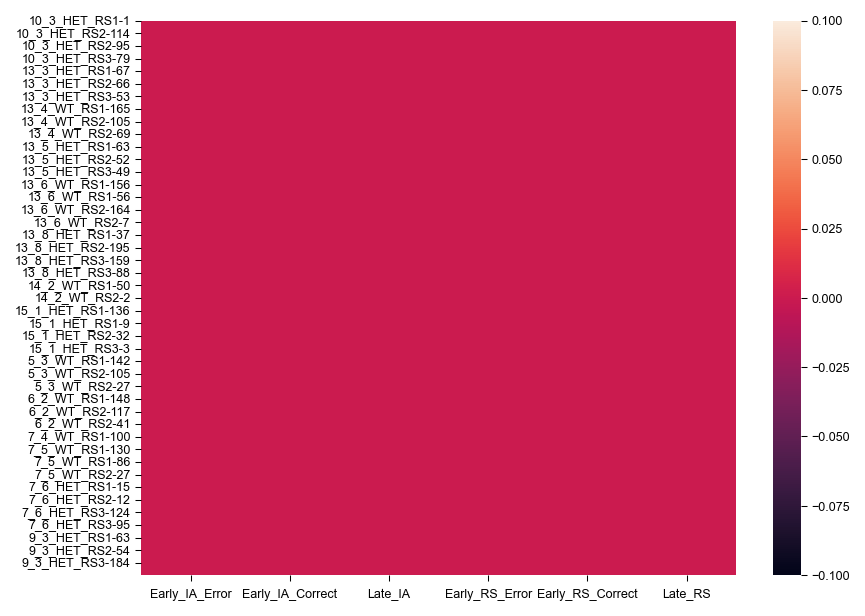

In [31]:
diff_cols = {s: (spike_mean_concat[s+"_canon"]- spike_mean_concat[s+"_new"]).astype(float) for s in stage_names}
canon_less_new_mean= pd.DataFrame(diff_cols)
#describe + plot
print(canon_less_new_mean.describe())
sns.heatmap(canon_less_new_mean.astype(float))

#### slice changed cells to further investigate

In [32]:
canon_cell_diff_bool = canon_less_new_mean != 0
canon_cell_diff_bool

,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
10_3_HET_RS1-1,False,False,False,False,False,False
10_3_HET_RS1-10,False,False,False,False,False,False
10_3_HET_RS1-101,False,False,False,False,False,False
10_3_HET_RS1-104,False,False,False,False,False,False
10_3_HET_RS1-107,False,False,False,False,False,False
...,...,...,...,...,...,...
9_3_HET_RS3-95,False,False,False,False,False,False
9_3_HET_RS3-96,False,False,False,False,False,False
9_3_HET_RS3-97,False,False,False,False,False,False
9_3_HET_RS3-98,False,False,False,False,False,False


#### Plot low-D projections: UMAP

In [33]:
canon_spikes_df, canon_umap_spikes_model = run_dimensionality_reduction( canon_spike_umap_input, method = 'umap', n_neighbors=15, min_dist=0.2, metric=metric,random_state=42)

canon_spike_cell_enrich = canon_mean_unit_tseries.groupby(by = 'unique_ID')[stage_names].first().astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
canon_spikes_df = canon_spikes_df.merge(canon_spike_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)
canon_spikes_df

Shape: (4776, 6) → (4776, 6)


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,dim1,dim2,method,first_active_stage
unique_ID,,,,
10_3_HET_RS1-1,14.955326,-13.225299,UMAP,Early_IA_Error
10_3_HET_RS1-10,11.758310,-0.566257,UMAP,Early_IA_Error
10_3_HET_RS1-101,-19.897745,22.507341,UMAP,Never
10_3_HET_RS1-104,7.116478,2.665500,UMAP,Late_IA
10_3_HET_RS1-107,5.358498,4.102057,UMAP,Never
...,...,...,...,...
9_3_HET_RS3-95,14.932246,-13.145504,UMAP,Never
9_3_HET_RS3-96,10.849854,-1.109410,UMAP,Never
9_3_HET_RS3-97,14.383278,-0.421262,UMAP,Early_IA_Error


In [34]:
# #plot nonenriched
# non_ensemble_df =  tsne_results[geno].loc[tsne_results[geno].ensemble == 'none',:]
# sns.scatterplot(**plot_params, data =non_ensemble_df,   s = 5,alpha = 0.5, linewidth =0.5, legend = False, palette = ['black'],  zorder=-1000)
# #find collections with > 1 point contained therein
# nonlegend_collections = [x for x in ax.collections if x.get_facecolors().shape[0]>1]
# collection_size= [x.get_facecolors().shape for x in nonlegend_collections]
# largest_collection_size = np.max(collection_size) #use largest collection as == ensemble 
# non_enrich_collection = [x for x in nonlegend_collections if x.get_facecolors().shape[0] == largest_collection_size][0]
# non_enrich_collection.set_edgecolors(non_enrich_collection.get_facecolors().copy())# Restore the edge colors using the saved values
# non_enrich_collection.set_facecolors("none")# Remove the face color by setting it to "none"
# #plot ensemble
# ensemble_df = tsne_results[geno].loc[tsne_results[geno].ensemble.isin(stage_chrono_order),:]
# sns.scatterplot(**plot_params, data =ensemble_df, s = 8,alpha = 0.6, legend = True, palette = [stage_palette_dict[x] for x in stage_chrono_order], hue_order =stage_chrono_order,zorder=100 )
# set_ax_title_xlabel_ylabel(ax,{'title': f" {geno} {transform}:",'ylabel': f'{transform} Dim. 2', 'xlabel': f'{transform} Dim. 1', 'xticks':[], 'yticks':[]})
# #get legend and move
# hand, labels = ax.get_legend_handles_labels()
# ax.get_legend().remove()
# fig.legend(hand, [x.replace('_', ' ') for x in labels], bbox_to_anchor=(0.5, 1),loc = 'lower center', ncol = 2, frameon = False, title = None, handletextpad=0.1, )
# #save fig 
# ax.set_box_aspect(1)

c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use 

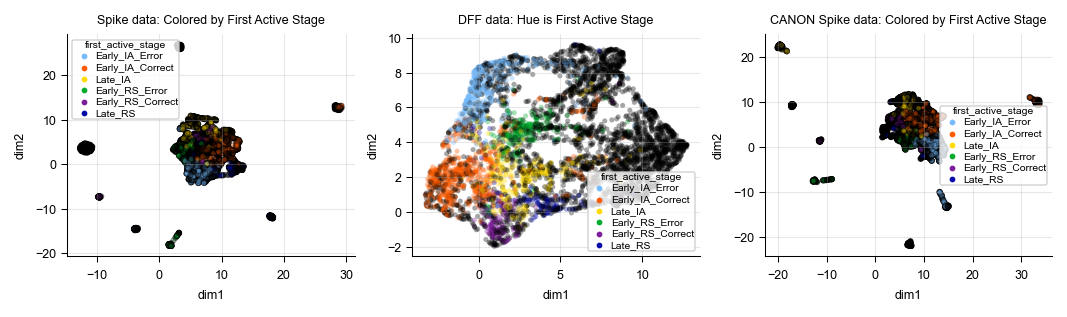

In [35]:
## PLOTTING- note that paper tSNE is projection of mean activity in stage, colored by ensemble identity
fig, axes = plt.subplots(1, 3, figsize=(7, 2), layout='constrained')
palette = [stage_palette_dict[x] for x in stage_names] + ['lightgray']
hue_col = 'first_active_stage'

#sne settings: NON ENRICHED:  s = 5,alpha = 0.35, linewidth =0.5, legend = False, palette = ['black'],  zorder=0
#ENRICHED: s = 6,alpha = 0.5, legend = make_legend, palette = [stage_palette_dict[x] for x in stage_chrono_order], hue_order =stage_chrono_order,zorder=100 )
alpha = 0.35
s_base = 6
# Spikes
sns.scatterplot(ax=axes[0], data=spikes_df, x='dim1', y='dim2', hue=hue_col,     palette=palette, hue_order=stage_names , s=s_base, alpha=alpha, edgecolor='k',linewidth=0.5, legend='full')
axes[0].set_title(f'Spike data: Colored by First Active Stage')
axes[0].grid(True, alpha=0.3)

# DFF
sns.scatterplot(ax=axes[1], data=dff_df, x='dim1', y='dim2', hue=hue_col, palette=palette, hue_order=stage_names , s=s_base, alpha=alpha, edgecolor='none',  linewidth=0.5, legend='full')
axes[1].set_title(f'DFF data: Hue is First Active Stage')
axes[1].grid(True, alpha=0.3)

# Spikes- CANON
sns.scatterplot(ax=axes[2], data=canon_spikes_df, x='dim1', y='dim2', hue=hue_col,     palette=palette, hue_order=stage_names , s=s_base, alpha=alpha, edgecolor='k',linewidth=0.5, legend='full')
axes[2].set_title(f'CANON Spike data: Colored by First Active Stage')
axes[2].grid(True, alpha=0.3)


#Final check- save manifest of config

In [36]:
subjects= unit_mean_tseries['subject_name'].unique().tolist()
enrichment_output_path = "None"
timeseries_output_path= "None"

In [37]:
# Cell: Save run manifest
runtime = time.time() - START_TIME

manifest = create_run_manifest(config=config, output_dir=run_output_dir, run_id=RUN_ID,
    inputs={'source_data': str(config['data']['source_dataset_location']),'n_subjects': len(subjects),},
    outputs={'shuffle_parquets': str(run_output_dir),
        'n_files': len(list(run_output_dir.glob('*.parquet'))),
        'enrichment_results': str(enrichment_output_path),
        'timeseries_results': str(timeseries_output_path),
    },
    performance={'runtime_seconds': int(runtime),'runtime_human': f"{runtime/3600:.1f} hours",'n_cores_used': config['shuffles']['n_cores'],},
    status={'success': True,'errors': [],'warnings': [],}
)

# Update central run log
run_db = update_run_database(manifest, db_path=results_dir / 'run_log.csv')
print(f"Run complete: {RUN_ID}")
print(f"Runtime: {runtime/3600:.1f} hours | Outputs: {run_output_dir}")
print(f"Manifest: {run_output_dir / f'run_manifest_{RUN_ID}.yaml'}")

[OK] Manifest saved to: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20251209_145452\run_manifest_20251209_145452.yaml
[OK] Run database updated: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\run_log.csv
     Total runs recorded: 33
Run complete: 20251209_145452
Runtime: 0.3 hours | Outputs: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20251209_145452
Manifest: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20251209_145452\run_manifest_20251209_145452.yaml


#### TEMP- COMPARE TIMESERIES

In [38]:
"""
CORRECTED Analysis - comparing matching neurons between CANON and NEW
"""

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Load data
canon_path = data_dir / "post_outcome_main_datasets_neurons_trial activity timeseries data_10-Dec-2024_timeseries.csv"
new_path = results_dir / save_name

print("="*80)
print("LOADING DATA")
print("="*80)
canon_df = pd.read_csv(canon_path)
# Re-load the newly generated data
new_df = trial_tseries_df_norm  # Or however you reference it
# new_df = pd.read_parquet(new_path)
print(f"CANON shape: {canon_df.shape}")
print(f"NEW shape: {new_df.shape}")

# Get time-series columns
canon_ts_cols = [col for col in canon_df.columns if 's to' in col]
new_ts_cols = [col for col in new_df.columns if 's to' in col]

print(f"\nTime-series columns: {len(canon_ts_cols)} (both files match)")

# ==============================================================================
# CALCULATE MEAN ACTIVITY BY TASK STAGE FOR EACH NEURON
# ==============================================================================
print("\n" + "="*80)
print("CALCULATING MEAN ACTIVITY BY TASK STAGE")
print("="*80)

# CANON - use unique_ID (not neuron_ID!)
canon_mean_by_stage = (canon_df.groupby(['neuron_ID', 'task_phase_vec'])[canon_ts_cols]
                       .mean()
                       .mean(axis=1)  # Mean across all timepoints
                       .reset_index(name='mean_activity'))

print(f"\nCANON mean activity shape: {canon_mean_by_stage.shape}")
print(f"Unique neurons in CANON: {canon_mean_by_stage['neuron_ID'].nunique()}")
print(f"Sample:\n{canon_mean_by_stage.head(10)}")

# NEW
new_mean_by_stage = (new_df.groupby(['neuron_id', 'task_phase_vec'])[new_ts_cols]
                     .mean()
                     .mean(axis=1)  # Mean across all timepoints
                     .reset_index(name='mean_activity'))

print(f"\nNEW mean activity shape: {new_mean_by_stage.shape}")
print(f"Unique neurons in NEW: {new_mean_by_stage['neuron_id'].nunique()}")
print(f"Sample:\n{new_mean_by_stage.head(10)}")

# ==============================================================================
# MERGE AND COMPARE
# ==============================================================================
print("\n" + "="*80)
print("MERGING AND COMPARING MEAN ACTIVITIES")
print("="*80)

# Rename for merging
canon_mean_renamed = canon_mean_by_stage.rename(columns={
    'unique_ID': 'neuron_id',
    'task_phase_vec': 'task_stage',
    'mean_activity': 'canon_mean'
})

new_mean_renamed = new_mean_by_stage.rename(columns={
    'task_phase_vec': 'task_stage',
    'mean_activity': 'new_mean'
})

# Merge
comparison = canon_mean_renamed.merge(
    new_mean_renamed,
    on=['neuron_id', 'task_stage'],
    how='outer',
    indicator=True
)

print(f"\nMerge result shape: {comparison.shape}")
print(f"\nMerge indicator counts:")
print(comparison['_merge'].value_counts())

# Calculate difference
comparison['difference'] = comparison['new_mean'] - comparison['canon_mean']
comparison['abs_difference'] = comparison['difference'].abs()
comparison['pct_difference'] = (comparison['difference'] / comparison['canon_mean']) * 100

# ==============================================================================
# ANALYZE DIFFERENCES
# ==============================================================================
print("\n" + "="*80)
print("DIFFERENCE STATISTICS")
print("="*80)

# Filter to only matching records
matched = comparison[comparison['_merge'] == 'both'].copy()
print(f"\nMatched neuron-stage pairs: {len(matched)}")
print(f"Unique neurons in matched pairs: {matched['neuron_id'].nunique()}")

print(f"\nDifference statistics:")
print(matched[['difference', 'abs_difference', 'pct_difference']].describe())

# Find cells with largest differences
print(f"\n\nTop 20 neuron-stage pairs with largest absolute differences:")
top_diffs = matched.nlargest(20, 'abs_difference')[
    ['neuron_id', 'task_stage', 'canon_mean', 'new_mean', 'difference', 'pct_difference']
]
print(top_diffs.to_string())

# Cells with any difference
cells_with_diff = matched[matched['abs_difference'] > 1e-10]['neuron_id'].unique()
print(f"\n\nCells with ANY difference (>1e-10): {len(cells_with_diff)}")
print(f"Total unique cells in comparison: {matched['neuron_id'].nunique()}")
print(f"Percentage with differences: {len(cells_with_diff)/matched['neuron_id'].nunique()*100:.1f}%")

# Cells with significant difference (>1% or >0.01 absolute)
cells_with_sig_diff = matched[
    (matched['abs_difference'] > 0.01) | (matched['pct_difference'].abs() > 1)
]['neuron_id'].unique()
print(f"\nCells with SIGNIFICANT difference (>1% or >0.01 abs): {len(cells_with_sig_diff)}")
print(f"Percentage: {len(cells_with_sig_diff)/matched['neuron_id'].nunique()*100:.1f}%")

# By stage analysis
print(f"\n\nDifferences by task stage:")
stage_stats = matched.groupby('task_stage').agg({
    'difference': ['mean', 'std', 'min', 'max'],
    'abs_difference': ['mean', 'max'],
    'neuron_id': 'count'
})
print(stage_stats)

# Check which neurons are missing
print("\n" + "="*80)
print("MISSING NEURONS")
print("="*80)

only_canon = comparison[comparison['_merge'] == 'left_only']['neuron_id'].unique()
only_new = comparison[comparison['_merge'] == 'right_only']['neuron_id'].unique()

print(f"\nNeurons only in CANON: {len(only_canon)}")
if len(only_canon) <= 20:
    print(f"  {sorted(only_canon)}")

print(f"\nNeurons only in NEW: {len(only_new)}")
if len(only_new) <= 20:
    print(f"  {sorted(only_new)}")

# ==============================================================================
# VISUALIZATION
# ==============================================================================
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter plot: CANON vs NEW
ax = axes[0, 0]
ax.scatter(matched['canon_mean'], matched['new_mean'], alpha=0.3, s=1)
ax.plot([matched['canon_mean'].min(), matched['canon_mean'].max()],
        [matched['canon_mean'].min(), matched['canon_mean'].max()],
        'r--', lw=2, label='y=x')
ax.set_xlabel('CANON Mean Activity')
ax.set_ylabel('NEW Mean Activity')
ax.set_title('CANON vs NEW Mean Activity\n(Each point = one neuron-stage pair)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Histogram of differences
ax = axes[0, 1]
ax.hist(matched['difference'], bins=100, edgecolor='black')
ax.set_xlabel('Difference (NEW - CANON)')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of Differences\nMean={matched["difference"].mean():.6f}, Std={matched["difference"].std():.6f}')
ax.axvline(0, color='red', linestyle='--', lw=2)
ax.grid(True, alpha=0.3)

# 3. Absolute difference by stage
ax = axes[1, 0]
stage_groups = matched.groupby('task_stage')['abs_difference']
stage_names = list(stage_groups.groups.keys())
stage_values = [stage_groups.get_group(s).values for s in stage_names]
ax.boxplot(stage_values, labels=stage_names)
ax.set_ylabel('Absolute Difference')
ax.set_xlabel('Task Stage')
ax.set_title('Absolute Difference Distribution by Task Stage')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# 4. Percentage difference distribution
ax = axes[1, 1]
# Filter out infinite and very large values for visualization
pct_diff_filtered = matched['pct_difference'][
    (matched['pct_difference'].abs() < 100) &
    (matched['pct_difference'].notna())
]
ax.hist(pct_diff_filtered, bins=100, edgecolor='black')
ax.set_xlabel('Percentage Difference (%)')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of % Differences\n(Filtered to ±100%)')
ax.axvline(0, color='red', linestyle='--', lw=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'timeseries_comparison.png', dpi=150, bbox_inches='tight')
print(f"\nSaved visualization to: {results_dir / 'timeseries_comparison.png'}")
plt.show()

# Save comparison data
comparison_path = results_dir / 'timeseries_comparison_detailed.parquet'
matched.to_parquet(comparison_path)
print(f"\nSaved detailed comparison to: {comparison_path}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nSUMMARY:")
print(f"  Neurons in CANON: 4776")
print(f"  Neurons in NEW: 4814")
print(f"  Neurons in both: 4676")
print(f"  Matched neuron-stage pairs: {len(matched)}")
print(f"  Pairs with ANY difference: {len(cells_with_diff)}")
print(f"  Pairs with SIGNIFICANT difference: {len(cells_with_sig_diff)}")

LOADING DATA


C:\Users\13car\AppData\Local\Temp\ipykernel_75140\814220657.py:17: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  canon_df = pd.read_csv(canon_path)


CANON shape: (191421, 413)
NEW shape: (92731, 95)

Time-series columns: 0 (both files match)

CALCULATING MEAN ACTIVITY BY TASK STAGE

CANON mean activity shape: (1481, 3)
Unique neurons in CANON: 247
Sample:
   neuron_ID    task_phase_vec  mean_activity
0          1  Early_IA_Correct            NaN
1          1    Early_IA_Error            NaN
2          1  Early_RS_Correct            NaN
3          1    Early_RS_Error            NaN
4          1           Late_IA            NaN
5          1           Late_RS            NaN
6          2  Early_IA_Correct            NaN
7          2    Early_IA_Error            NaN
8          2  Early_RS_Correct            NaN
9          2    Early_RS_Error            NaN

NEW mean activity shape: (27609, 3)
Unique neurons in NEW: 4749
Sample:
         neuron_id    task_phase_vec  mean_activity
0   10_3_HET_RS1-1  Early_IA_Correct       0.000000
1   10_3_HET_RS1-1    Early_IA_Error       0.669444
2   10_3_HET_RS1-1  Early_RS_Correct       0.000000
3   

KeyError: 'neuron_id'

In [ ]:
# For this neuron (13_4_WT_RS2-42) in trial 4:
# What are the RAW frame values (before binning) in the pre-outcome section?

# In the raster DataFrame (before extract_trial_windows), for trial 4:
test_subject = '13_4_WT_RS2'  # Adjust to match your subject naming
test_neuron_idx = 42  # Adjust if needed

# Get the raw raster for this subject
subject_df = raster_dataframes[test_subject]  # or whatever your dict is called

# Filter to trial 4, pre_outcome section
trial_4_pre = subject_df[(subject_df['trial_num'] == 4) & (subject_df['trial_section'] == 'pre_outcome')]

# Show the activity values for this neuron
cell_col = 'cell_42'  # or however it's named
print(f"Number of pre-outcome frames in trial 4: {trial_4_pre.shape}")
print(f"Cell activity in these frames:")
print(trial_4_pre[cell_col].values)